### pytorch workflow
lets just began


In [ ]:
what_were_covereing = {1:"data (prepare and load)",
                       2:"build model",
                       3:"fitting the model to data(training)",
                       4:"evaluate the model",
                       5:"saving and loading a model",
                       6:"putting it all together"}
what_were_covereing

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data(training)',
 4: 'evaluate the model',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [ ]:
import torch
from torch import nn #nn contains all of the pytorch's building blocks for nueral netwroks
import matplotlib.pyplot as plt

#check pytorch version
torch.__version__

'2.11.0+cu128'

## 1.Data(preapring and loading)
Data can be almost anything.... in machine learning
* Excel speadsheet
* Images of any kind
* Videos
* Audio like songs or prodcasts
* DNA
* Text

### Machine learning :a game of two part


1.   Get data into numerical rpresentation
2.   Build a model to learn patterns in that numerical representation

To showcase this , lets create
some known data using the linear regression formula


In [ ]:
# create *known* parameters
weight = 0.7
bias = 0.3

#create
start =0
end = 1
step =0.02
X = torch.arange(start,end,step).unsqueeze(dim=1)
Y = weight*X+bias

X[:10],Y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
len(X),len(Y)

(50, 50)

### spliting data into training and testing most important in machine learning

lets create a training and test with of our data

In [ ]:
#crete a train\test split
train_split = int(0.8*len(X))
X_train,Y_train = X[:train_split],Y[:train_split]
X_test,Y_test=X[train_split:],Y[train_split:]
len(X_train),len(Y_train),len(X_test),len(Y_test)

(40, 40, 10, 10)

How might we better visualize our data?
THis is where data explorers motto come in
"Visualize , visualize,visua;ize"

In [ ]:
def plot_predictions(train_data= X_train,
                     train_labels = Y_train,
                     test_data = X_test,
                     test_labels = Y_test,
                     predictions=None,
                     ):
  """
  plots training data , test data and compare predictions
  """

  plt.figure(figsize=(10,7))
  #plot training data in blue
  plt.scatter(train_data,train_labels,c="b",s=4,label="Training data")

  #plot test data in green
  plt.scatter(test_data,test_labels,c ="g",s=4, label ="Testing data")

  #Are rher predictions?
  if predictions is not None:
    # Plot the predictions if they exit
    plt.scatter(test_data,predictions,c="r",s=4,label = "predictions")
  #show thw legend
  plt.legend(prop ={"size":14});


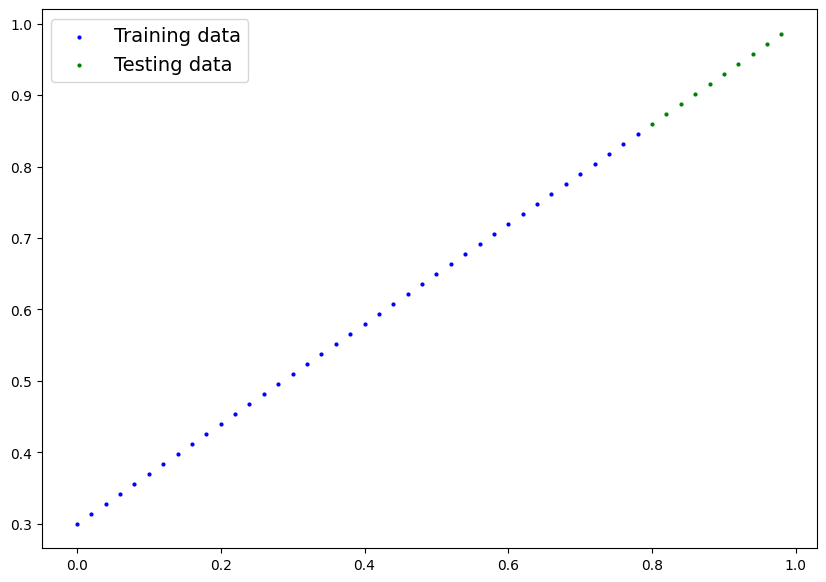

In [ ]:
plot_predictions()

## Building model
 Our first Pytorch model
 What pur model does:
 * start with random values(weight &bais)
 * Look at training data  and adjust the random values to better represent(or closer to) to the ideal values (wight and bias values we used to create the data )

 How does it do so?
 Through two main algorithims:
 1. Geadient descent
 2. Backpropagation

In [ ]:
from torch import nn

# create linear regression model class

class LinearRegressionModel(nn.Module): #<- almost everything in Pytorch  inherits from nn.Models
  def __init__(self):
    super().__init__()

    #Initialize model parameters
    self.weights = nn.Parameter(torch.randn(1,
                                             requires_grad = True,
                                             dtype = torch.float))
    self.bias =nn.Parameter(torch.randn(1,
                                       requires_grad = True,
                                       dtype = torch.float))

    #Forward mathod to define the computation in the model

  def forward(self,X:torch.Tensor)->torch.Tensor: # <- "X" is the input data
    return self.weights*X+self.bias #this is the linear regression formula




### PyTorch model building essentials

* torch.nn - contains all of the building blocks for computational graphs(a nueral network can be considered )
* torch.nn.Parameter - what parameter should our model try and learn ,often a pytorch layer from torch.nn set this for us
* torch.nn.Module - The base class for all neural network modules ,if you subclss ,you should overwrite forward()
* torch.optim - this where the oprimizers in pytorch live, they will help with gradient descent
* def forward() - All nn.Model subclasses require you to write forward() this mathod defines what happens in the foward computation

### checking the content of ur pytorch model
How we 've created a model,lets see whats inside model
so we can check our model parametrrs or whats inside our model using .parameters()


In [ ]:
#create a random seed
torch.manual_seed(42)

#create an instance of model(this is a subclass of nn.Module)
model_0 = LinearRegressionModel ()

# CHeck out parameters
list(model_0.parameters())


[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
# List named parameters
model_0.state_dict()


OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
weight,bias

(0.7, 0.3)

### Making prediction using 'torch.inference_mode()'
To check our model's predictive power,lets see how well it predicts y_test baseed on x_test.

When we passd ata through ourr model, its going to run it through the forward() method.

In [ ]:
Y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

In [ ]:
Y_preds = model_0(X_test)
Y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [ ]:
# Make prediction with model
with torch.inference_mode():
  y_preds = model_0(X_test)

#infrence mode is prefered
# with torch.no_grad():
#   y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

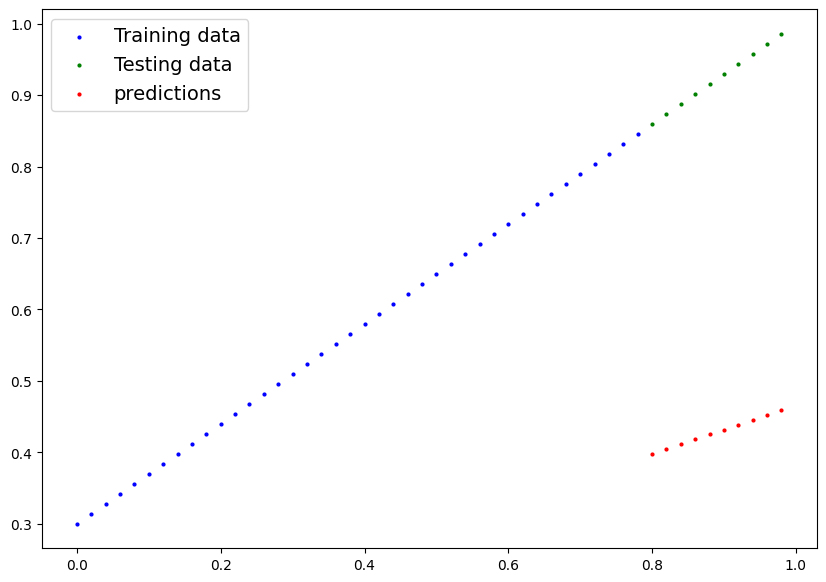

In [ ]:
plot_predictions(predictions = y_preds)

### 3. Train model
The whole idea of training is for a model  to move from some unknown parameters(these may be random) to some known parameters.

Or in other words from a poor represntation of the data to a better representation of the data

One way to measure how pooror how wrong models predictions are through loss functions

*Note : Loss function may also be called cost function or criteriob in differenr areas.For our case, we are going to refer to it as a loss function

Things we need to train :

* **Lost function:** A fuction to measure how wrong your models predictions are to the ideal ouputs,lower is better

* **Optimizer :** Takes into account the loss of a model and adjust the models parameters(eg weight and bias) to improve the loss function
    Inside the optimizer you will often have set two parameters:
    * params - the model parameters you'd lik to optimisze , for example params = model_0.parameters()
    * lr (learnig rate)- the learning rate is a hyperparameter that defines how big/small the optimizer changes the parameters with each step ( a small lr results in small changes , a  long lr results in large changes)



And specifically for pytorch we need:
1. A Traing loop
2. A testing loop


In [ ]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
# check out our models parameter(a parameter is a value that the model sets itself)
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
# set up a loss function
loss_fn = nn.L1Loss()

# Set up and optimizers(stochastic gradiemt descent)
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr=0.01 # lr = learning rate= possibly the most important hyperparameter
                            )

Q:Which loss function and optimizer should i use?

A:This will be problem specific. But with experince , you will get an idea of what works and what doesnt with your particular problem set.

For example , for a regression problem(like ours) a loss function of nn.L1Loss()and an optimizer like torch.optim.SGD() will suffice

But for a classification problem like classifying whether a photo is of a dog or a cat, you will likely want to use a loss function of nn.BCELoss() (binary cross entropy loss)



### Building a Training loop ( and a testing loop) in Pytorch
A couple of things we need in a training loop:

0. Loop through the data...
1. Forward pass(this involves data moving through our models forward() functions) to make predictions on data - also called forward propagation
2. Calculate the loss(compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of  each of the paramters of our model with respect to the loss (**backpropagation**)
5. Optimizer step - Use the optimizer to adjust our model's paramter to trys and improve the loss (**gradient descent**)


In [ ]:
X_test,Y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [ ]:
# An epoch is one loop through the data
epochs = 200

#Track the different values
epoch_count = []
loss_values = []
test_loss_values = []

### Training
for epoch in range(epochs):

    # 0. Put model in training mode
    model_0.train()

    # 1. Forward pass
    y_pred = model_0(X_train)

    # 2. Calculate the loss
    loss = loss_fn(y_pred, Y_train)

    # 3. Zero the gradients
    optimizer.zero_grad()

    # 4. Backpropagation
    loss.backward()

    # 5. Update the parameters
    optimizer.step()

    ### Testing
    model_0.eval()
    # print("loss:",loss)

    with torch.inference_mode():

        # 1. Forward pass
        test_pred = model_0(X_test)

        # 2. Calculate test loss
        test_loss = loss_fn(test_pred, Y_test)


    # Print every 10 epochs
    if epoch % 10 == 0:
      epoch_count.append(epoch)
      loss_values.append(loss)
      test_loss_values.append(test_loss)
      print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")


# Model parameters after training
print(model_0.state_dict())


Epoch: 0 | Loss: 0.31288138031959534 | Test loss: 0.48106518387794495
Epoch: 10 | Loss: 0.1976713240146637 | Test loss: 0.3463551998138428
Epoch: 20 | Loss: 0.08908725529909134 | Test loss: 0.21729660034179688
Epoch: 30 | Loss: 0.053148526698350906 | Test loss: 0.14464017748832703
Epoch: 40 | Loss: 0.04543796554207802 | Test loss: 0.11360953003168106
Epoch: 50 | Loss: 0.04167863354086876 | Test loss: 0.09919948130846024
Epoch: 60 | Loss: 0.03818932920694351 | Test loss: 0.08886633068323135
Epoch: 70 | Loss: 0.03476089984178543 | Test loss: 0.0805937647819519
Epoch: 80 | Loss: 0.03132382780313492 | Test loss: 0.07232122868299484
Epoch: 90 | Loss: 0.02788739837706089 | Test loss: 0.06473556160926819
Epoch: 100 | Loss: 0.024458957836031914 | Test loss: 0.05646304413676262
Epoch: 110 | Loss: 0.021020207554101944 | Test loss: 0.04819049686193466
Epoch: 120 | Loss: 0.01758546568453312 | Test loss: 0.04060482233762741
Epoch: 130 | Loss: 0.014155393466353416 | Test loss: 0.03233227878808975
Ep

In [ ]:
import numpy as np
np.array(torch.tensor(loss_values).numpy())


array([0.31288138, 0.19767132, 0.08908726, 0.05314853, 0.04543797,
       0.04167863, 0.03818933, 0.0347609 , 0.03132383, 0.0278874 ,
       0.02445896, 0.02102021, 0.01758547, 0.01415539, 0.01071659,
       0.00728353, 0.00385178, 0.00893248, 0.00893248, 0.00893248],
      dtype=float32)

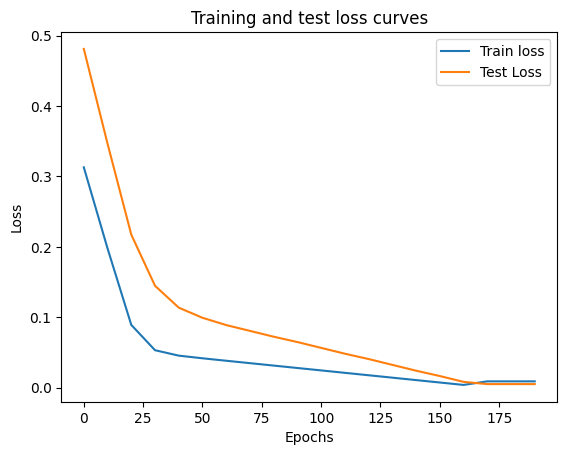

In [ ]:
#plot the loss curves
plt.plot(epoch_count,np.array(torch.tensor(loss_values).numpy()) ,label = 'Train loss')
plt.plot(epoch_count,test_loss_values,label ="Test Loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()


In [ ]:
weight,bias

(0.7, 0.3)

In [ ]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)
y_preds_new

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

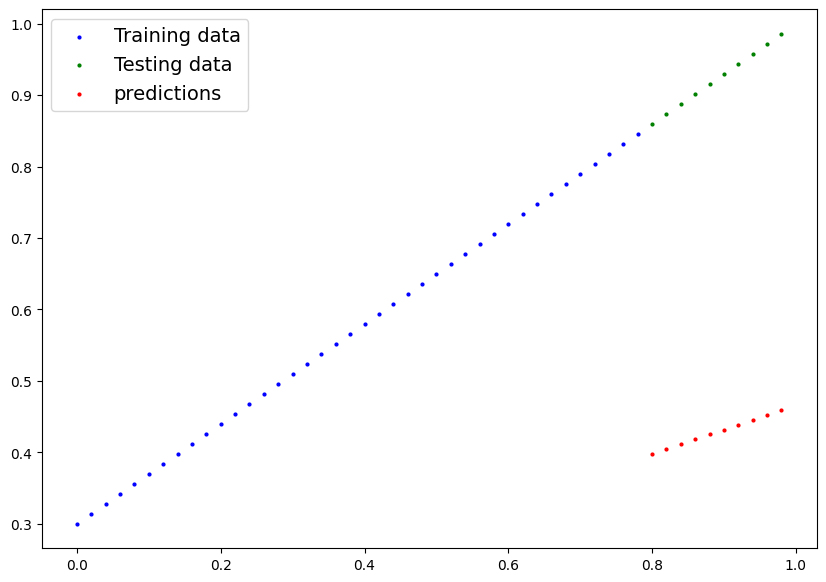

In [ ]:
plot_predictions(predictions = y_preds)

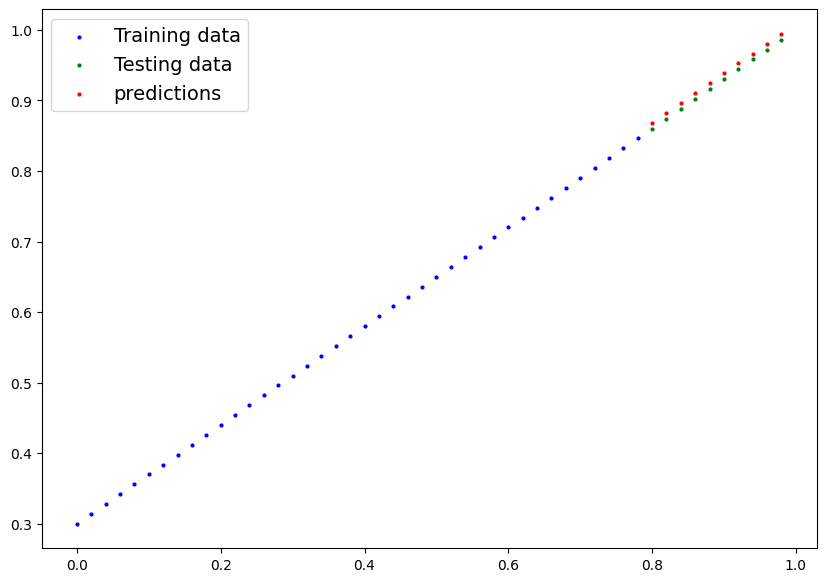

In [ ]:
plot_predictions(predictions = y_preds_new)

### saving model in pytorch
There are three main mathods for saving and loading models in Pytorch

1. torch.save() - allows to save a pytorch object in pythons pickle format
2. torch.load() - allows you to load a saved pytorch object

3. torch.nn.Module.load_state_dic()- this allows to load a models saved  dictionary

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
# Saving pytorch model
from pathlib import Path

# 1.Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True , exist_ok = True)

#2. create model save path
MODEL_NAME = '01_pytorch_workflow_model_0.pth'
MODEL_SAVE_PATH = MODEL_PATH/MODEL_NAME
MODEL_SAVE_PATH

#3 . Save the model using save_dict
print(f"Saving model to {MODEL_SAVE_PATH}")
torch.save(obj = model_0.state_dict(),
           f = MODEL_SAVE_PATH)


Saving model to models/01_pytorch_workflow_model_0.pth


In [ ]:
ls -l models

total 8
-rw-r--r-- 1 root root 2117 Sep 14 02:31 01_pytorch_workflow_model_0.pth
-rw-r--r-- 1 root root 2245 Sep 14 01:53 O1_pytorch_workflow_model_1.pth


### Loading a pytorch model
since we saved our model state_dic() rather the entire model,we will create a new instance of our model class and load the saved state_dict() into that

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
# TO load in a saved_dict we have to instatiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

# LOad the saved state_dict of model_0(this will update new instance with updated parameter)
loaded_model_0.load_state_dict(torch.load(f= MODEL_SAVE_PATH))

<All keys matched successfully>

In [ ]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
#make some prediction
loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)
loaded_model_preds


tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [ ]:
# compare loaded model preds with orignial model oreds
y_preds == loaded_model_preds

tensor([[False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False]])

In [ ]:
#Make some models preds
model_0.eval()
with torch.inference_mode():
  y_preds = model_0(X_test)
y_preds == loaded_model_preds



tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

### 6. Putting it all together
Lets go back through the steps above and se it all in one place

In [ ]:
# import pytorch and matplotlib
import torch
from torch import nn
import matplotlib.pyplot as plt

#check Pytorch version'
torch.__version__

'2.11.0+cu128'

Create device-agnostic code
This means if we have gto access to a GPU our code will use it(for potentially faster computing).
If no Gpu is available , the code will default to using CPU

In [ ]:
#Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device:{device}")

Using device:cuda


### Data

In [ ]:
# Create some data using linear regression formula y = weight*X+ bias
weight = 0.7
bias = 0.3

# Create range values
start = 0
end = 1
step = 0.02

# Create X and Y (features and labels)
X = torch.arange(start,end,step).unsqueeze(dim=1) # without unsqueeze errors will pop
y = weight *X +bias
X[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
# Split sata
train_split = int(0.8*len(X))
X_train,y_train = X[:train_split] , y[:train_split]
X_test,y_test = X[train_split:],y[train_split:]
len(X_train),len(y_train),len(X_test),len(y_test)

(40, 40, 10, 10)

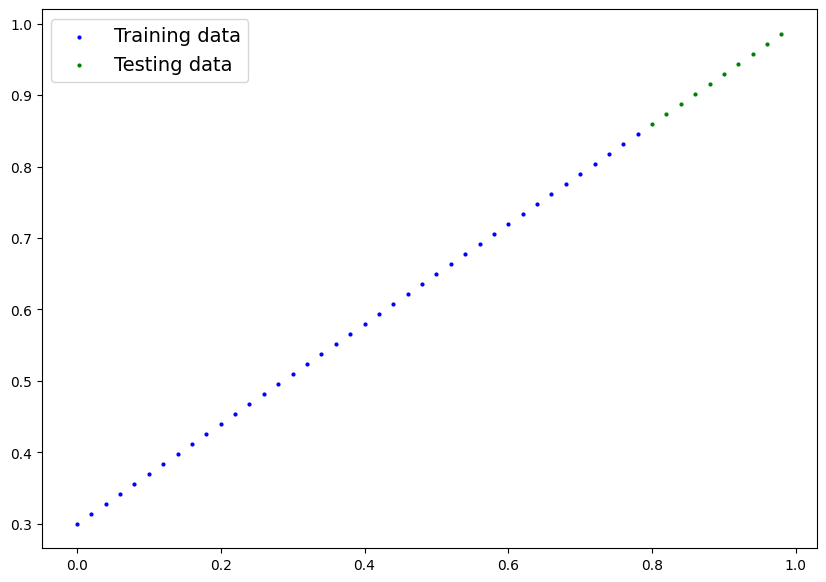

In [ ]:
# Plot the data
plot_predictions(X_train,y_train,X_test,y_test)

## Building a Pytorch linear model

In [ ]:
# Create a linear model by subclassing nn.Module
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    # Use nn.Linear() for creating model paramters/also called linear transformer,probing layer ,fully connected layer
    self.linear_layer = nn.Linear(in_features = 1,
                                  out_features=1)
  def forward(self, X:torch.Tensor)-> torch.Tensor:
    return self.linear_layer(X)


# Set the manual seed

torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1 , model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [ ]:
# check the model current device
next(model_1.parameters()).device

device(type='cpu')

In [ ]:
# Set the model to use the target device
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

### 6.3 Training
For training we need:
* Loss function
* Optimizer
* Training Loop
* Testing Loop

In [ ]:
# Set up loss function
loss_fn = nn.L1Loss() # same as MAE

# setup our optimizer
optimizer = torch.optim.SGD(params = model_1.parameters(),lr= 0.01)


In [ ]:
#Lets write a training loop
torch.manual_seed(42)
epochs = 200
# put data on target device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  model_1.train()

  # 1. forward pass
  y_pred = model_1(X_train)

  # 2. calculate the loss
  loss = loss_fn(y_pred,y_train)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. perform backpropagation
  loss.backward()

  # 5. optimizer step
  optimizer.step()

### Testing'

  model_1.eval()
  with torch.inference_mode():
    test_pred = model_1(X_test)
    test_loss = loss_fn(test_pred,y_test)

  # Print out whats happedning
  if epoch %10 ==0:
    print(f"epoch :{epoch} | loss:{loss} | Test loss:{test_loss}")


epoch :0 | loss:0.5551779270172119 | Test loss:0.5739762187004089
epoch :10 | loss:0.4399681091308594 | Test loss:0.4392664134502411
epoch :20 | loss:0.3247582018375397 | Test loss:0.30455657839775085
epoch :30 | loss:0.20954833924770355 | Test loss:0.16984669864177704
epoch :40 | loss:0.09433844685554504 | Test loss:0.03513690456748009
epoch :50 | loss:0.023886388167738914 | Test loss:0.04784907028079033
epoch :60 | loss:0.019956795498728752 | Test loss:0.045803118497133255
epoch :70 | loss:0.016517987474799156 | Test loss:0.037530567497015
epoch :80 | loss:0.013089174404740334 | Test loss:0.02994490973651409
epoch :90 | loss:0.009653178043663502 | Test loss:0.02167237363755703
epoch :100 | loss:0.006215683650225401 | Test loss:0.014086711220443249
epoch :110 | loss:0.00278724217787385 | Test loss:0.005814164876937866
epoch :120 | loss:0.0012645035749301314 | Test loss:0.013801801018416882
epoch :130 | loss:0.0012645035749301314 | Test loss:0.013801801018416882
epoch :140 | loss:0.001

In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [ ]:
weight,bias

(0.7, 0.3)

In [ ]:
# Turn mode into evaluatio  mode
model_1.eval()

# make predcitio n on the test data
with torch.inference_mode():
  y_preds = model_1(X_test)
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

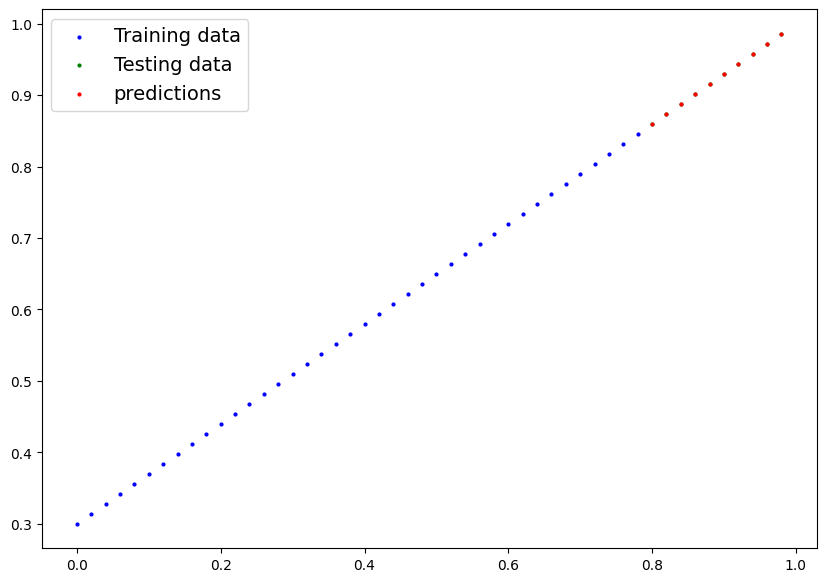

In [ ]:
# check out model predictions visualy

plot_predictions(predictions = y_preds.cpu())

### 6.5 Loading and saving model

In [ ]:
from pathlib import Path
# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True , exist_ok= True )

# 2 . create model save path
MODEL_NAME = "O1_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH/MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj = model_1.state_dict(),
           f = MODEL_SAVE_PATH)

Saving model to: models/O1_pytorch_workflow_model_1.pth


In [ ]:
# Load a pytorch model

# Create a new instance of linear regression model V2
loaded_model_1 = LinearRegressionModelV2()

# load the saved model_1 state_dict
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

# put the loaded model to device
loaded_model_1.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
next(loaded_model_1.parameters()).device

device(type='cuda', index=0)

In [ ]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [ ]:
# Evaluate loaded model
loaded_model_1.eval()
with torch.inference_mode():
  loaded_model_1_preds = loaded_model_1(X_test)
y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')